/tmp/ipykernel_17/2020184979.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


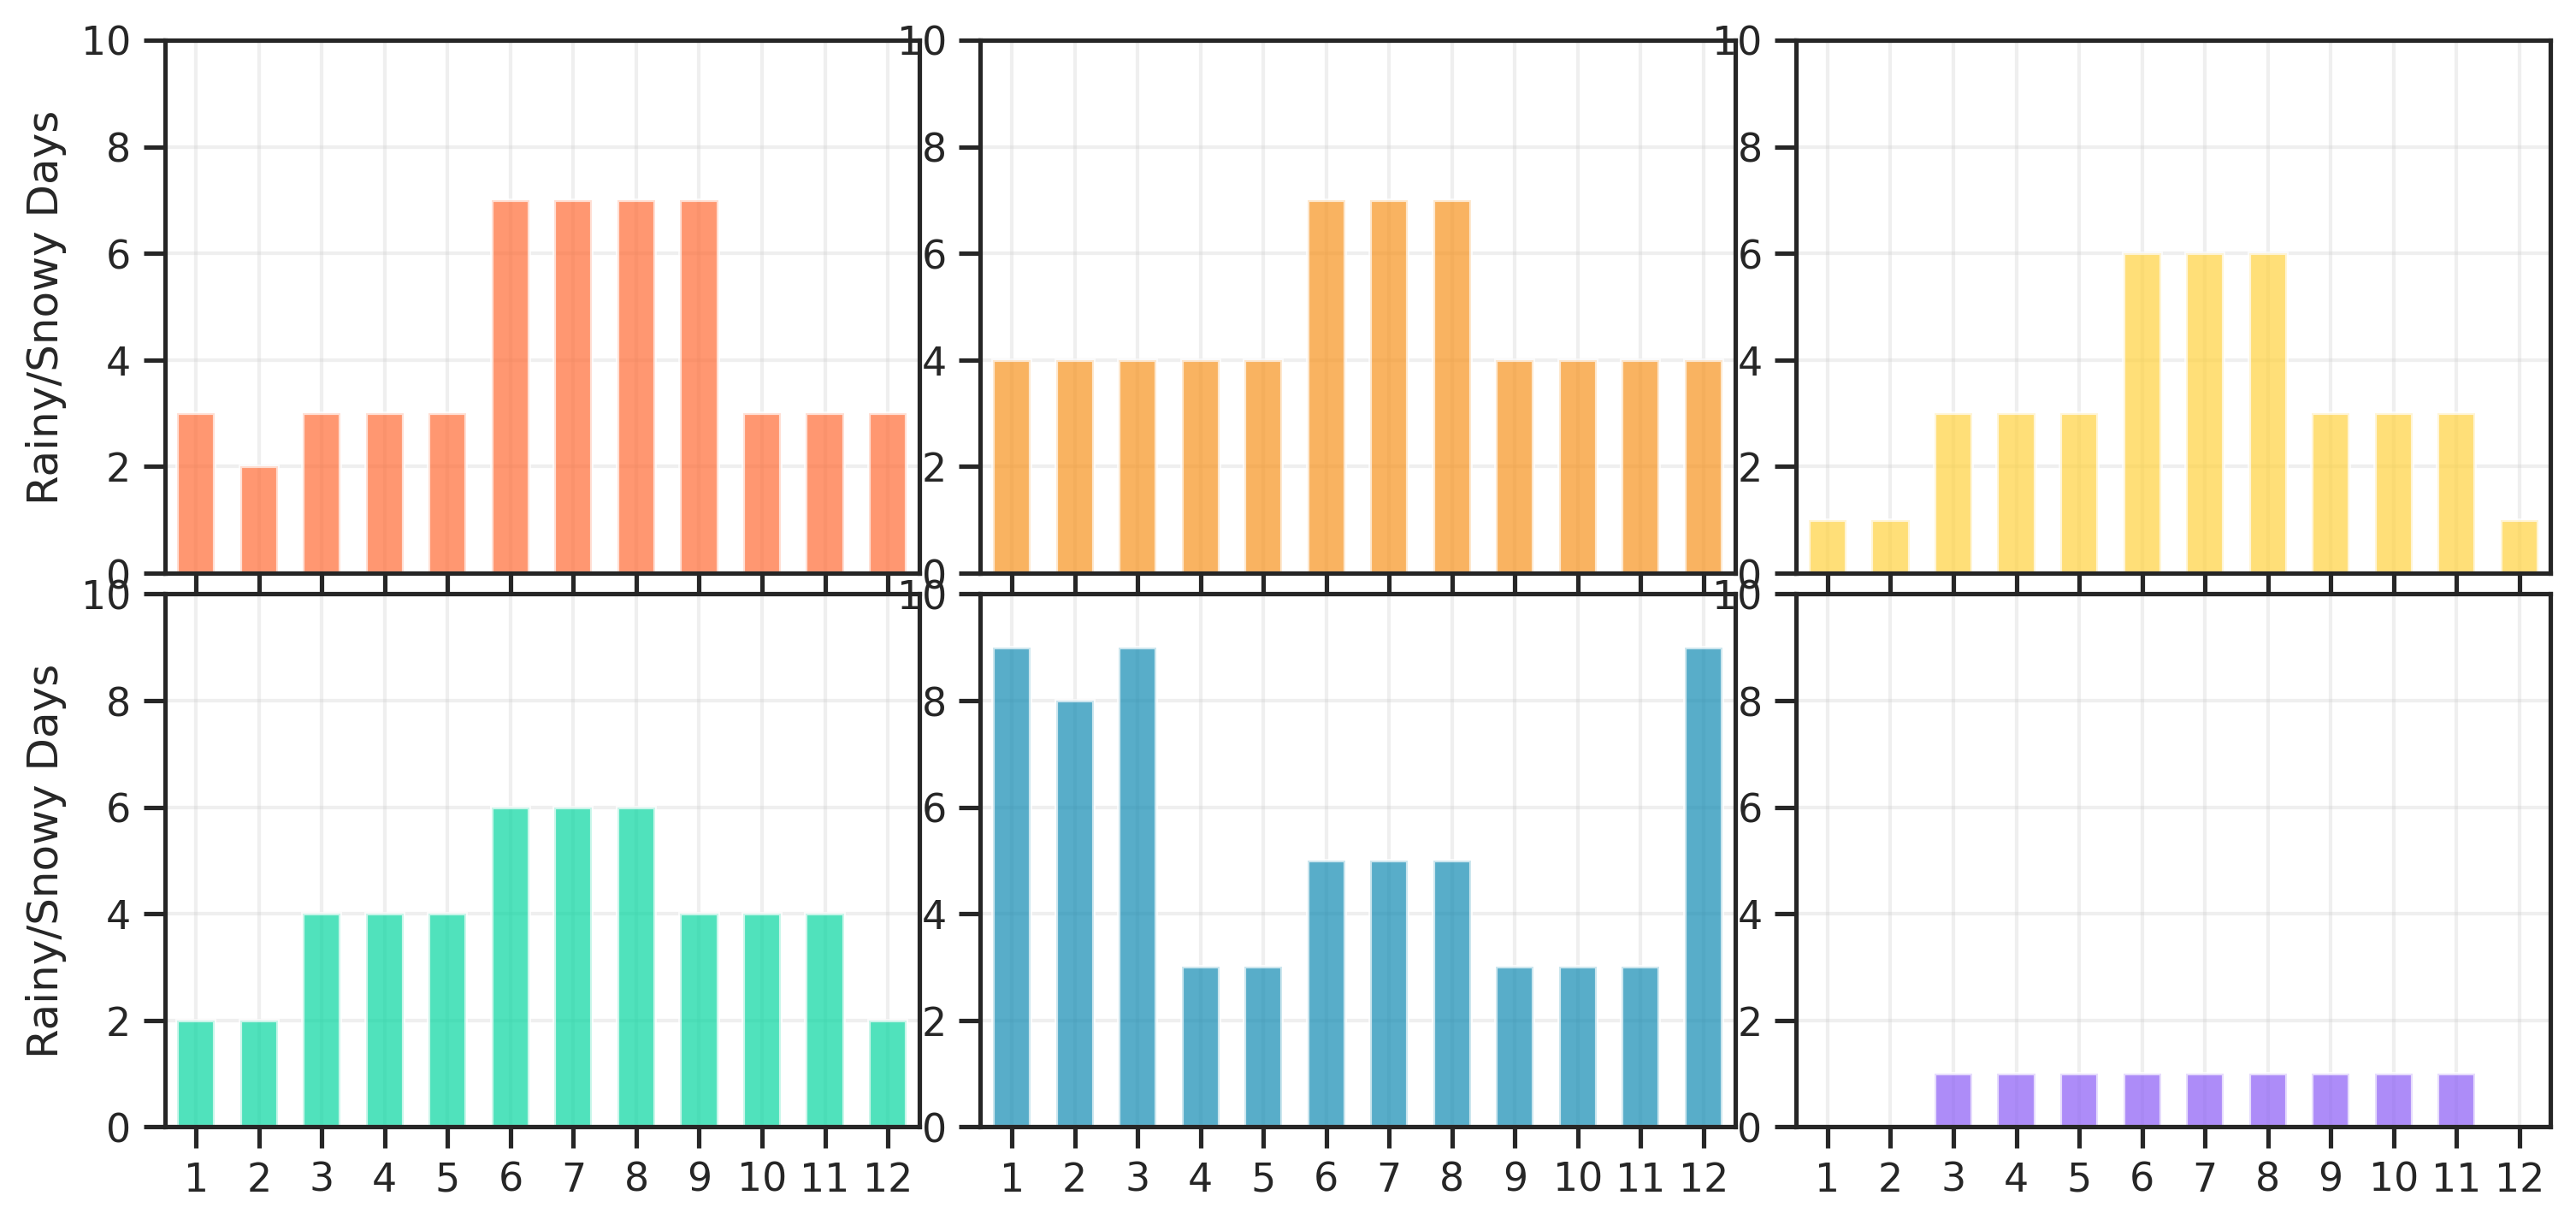

/tmp/ipykernel_17/2020184979.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


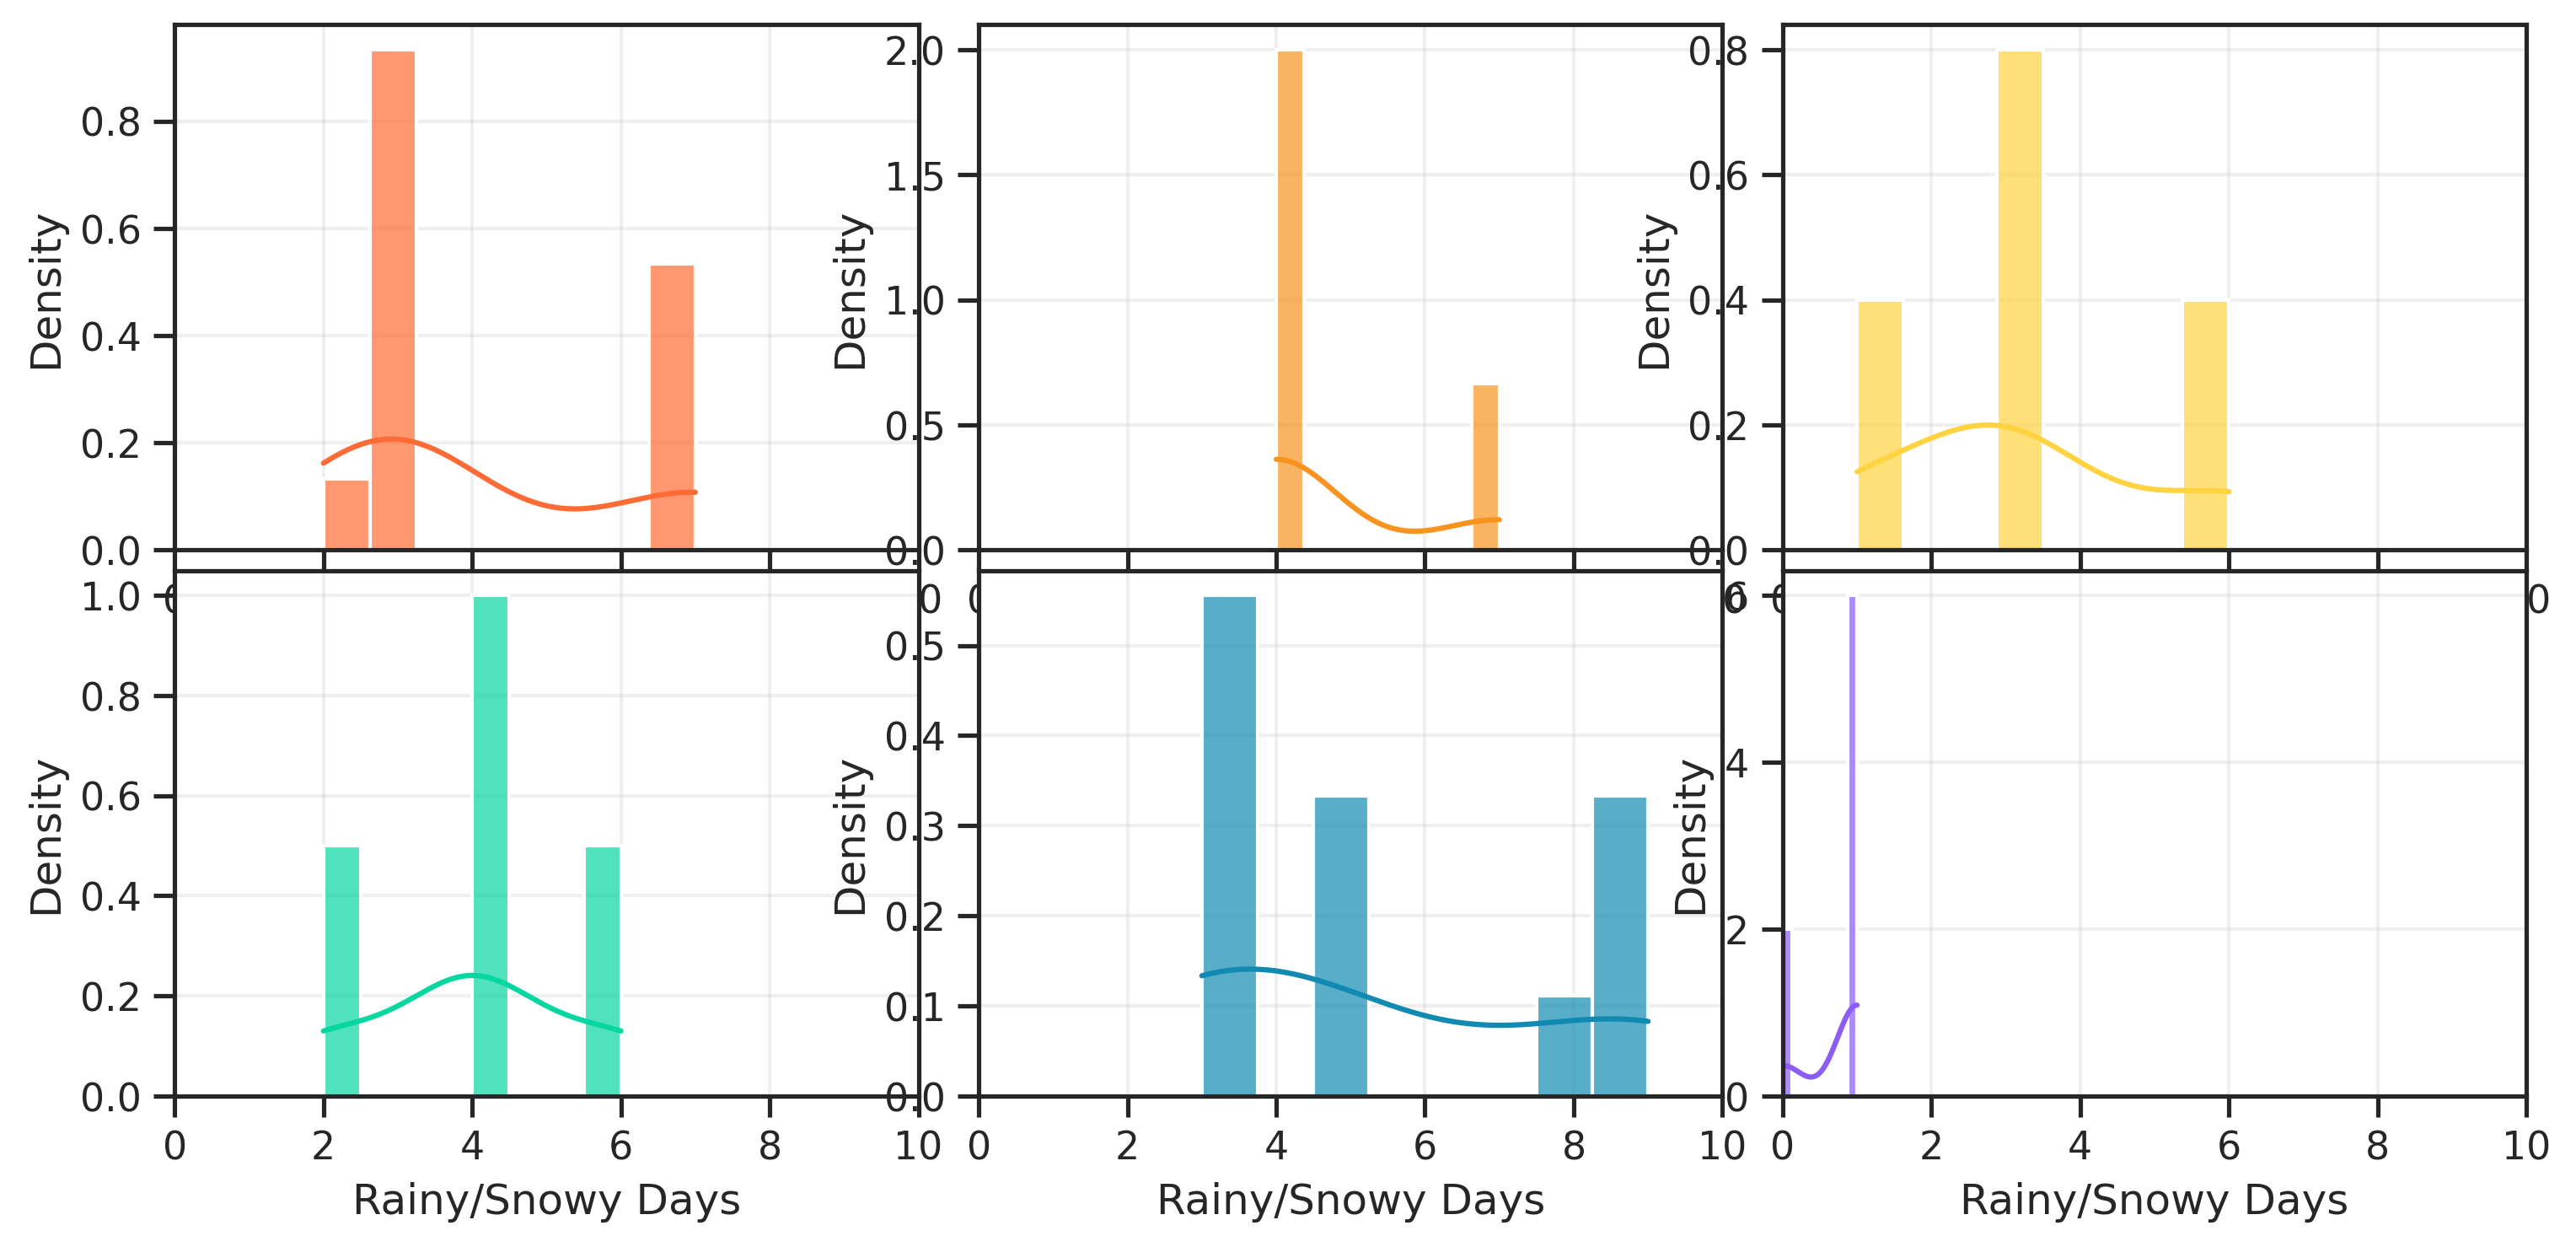

In [1]:
!pip install scienceplots
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
from typing import List
import scienceplots
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family']='Times New Roman'
plt.rcParams['axes.unicode_minus']= False
sns.set(style='ticks')
plt.style.use(sorted(plt.style.available)[31])

node_18_PV_labels = pd.read_csv(r"/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_labels.csv")

def analyze_rainy_snowy_days_by_climate(df):
    climate_ranges = {
        'climate_0': (0, 100),
        'climate_1': (100, 200),
        'climate_2': (200, 300),
        'climate_3': (300, 400),
        'climate_4': (400, 450),
        'climate_5': (450, 500)
    }

    days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_labels = []
    for month, days in enumerate(days_per_month, 1):
        month_labels.extend([month] * days)

    monthly_stats = {}
    
    for climate, (start_idx, end_idx) in climate_ranges.items():
        climate_columns = [f'Series_{i+1}' for i in range(start_idx, end_idx)]
        climate_data = df[climate_columns]

        monthly_rainy_days = []
        
        for month in range(1, 13):
            month_mask = np.array(month_labels) == month
            month_data = climate_data.iloc[month_mask]
            rainy_days_per_series = (month_data == 2).sum(axis=0)
            avg_rainy_days = rainy_days_per_series.mean()
            monthly_rainy_days.append(avg_rainy_days)
        
        monthly_stats[climate] = monthly_rainy_days
    
    return monthly_stats

def plot_climate_rainy_distribution(monthly_stats):
    fig = plt.figure(figsize=(12, 5.5))
    grid = plt.GridSpec(40, 30, wspace=3, hspace=3) 

    ax1 = fig.add_subplot(grid[:20, :10])
    ax2 = fig.add_subplot(grid[:20, 10:20])
    ax3 = fig.add_subplot(grid[:20, 20:30]) 
    ax4 = fig.add_subplot(grid[20:, :10])
    ax5 = fig.add_subplot(grid[20:, 10:20])
    ax6 = fig.add_subplot(grid[20:, 20:30])
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]
    colors = ['#FF6B35', '#F7931E', '#FFD23F', '#06D6A0', '#118AB2', '#8B5CF6']
    
    months = np.arange(1, 13)
    
    for i, (climate_key, ax) in enumerate(zip(monthly_stats.keys(), axes)):
        rainy_days = monthly_stats[climate_key]
        color = colors[i]

        bars = ax.bar(months, rainy_days, color=color, alpha=0.7, width=0.6)

        ax.set_xlim(0.5, 12.5)
        ax.set_ylim(0, 10)
        ax.set_xticks(months)
        ax.set_xticklabels(months)

        if i >= 3:
            ax.set_xlabel('')
        else:
            ax.set_xticklabels([])

        if i % 3 == 0:
            ax.set_ylabel('Rainy/Snowy Days')

        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_climate_rainy_distplot(monthly_stats):
    fig = plt.figure(figsize=(12, 5.5))
    grid = plt.GridSpec(40, 30, wspace=3, hspace=3) 

    ax1 = fig.add_subplot(grid[:20, :10])
    ax2 = fig.add_subplot(grid[:20, 10:20])
    ax3 = fig.add_subplot(grid[:20, 20:30]) 
    ax4 = fig.add_subplot(grid[20:, :10])
    ax5 = fig.add_subplot(grid[20:, 10:20])
    ax6 = fig.add_subplot(grid[20:, 20:30])
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]
    colors = ['#FF6B35', '#F7931E', '#FFD23F', '#06D6A0', '#118AB2', '#8B5CF6']
    
    for i, (climate_key, ax) in enumerate(zip(monthly_stats.keys(), axes)):
        rainy_days = monthly_stats[climate_key]
        color = colors[i]

        sns.histplot(rainy_days, kde=True, color=color, alpha=0.7, ax=ax, 
                    stat='density', bins=8)

        ax.set_xlim(0, 10)
        ax.set_xlabel('Rainy/Snowy Days')
        ax.set_ylabel('Density')

        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

monthly_stats = analyze_rainy_snowy_days_by_climate(node_18_PV_labels)

plot_climate_rainy_distribution(monthly_stats)

plot_climate_rainy_distplot(monthly_stats)



































